# Practical Plot Recipes

This notebook collects practical plotting snippets built with Python, Matplotlib, and `pythermalcomfort`.
These are example workflows (not package plotting APIs) to help users build meaningful figures quickly.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pythermalcomfort.models import pmv_ppd_iso, utci
from pythermalcomfort.plots.matplotlib import ThresholdPlot

## 1) Time-Series PMV with Comfort Band

Shows how PMV changes over time and highlights the common comfort interval (-0.5 to +0.5).


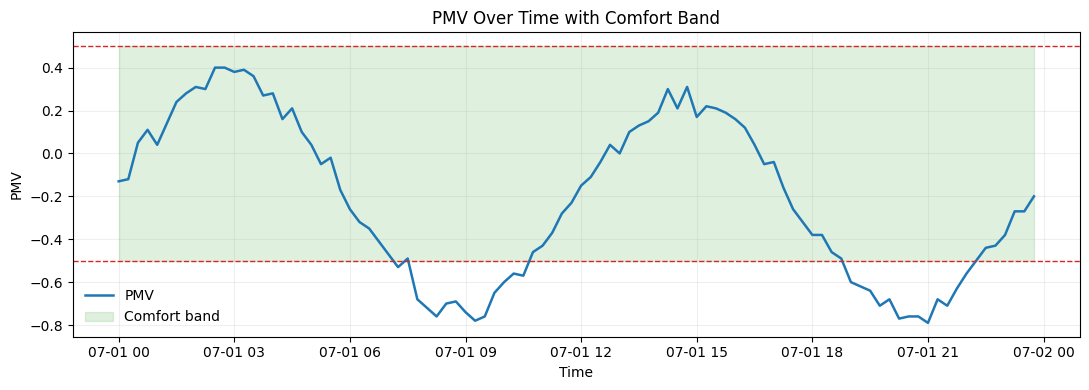

In [2]:
# Synthetic indoor dataset
n = 96
ts = pd.date_range("2026-07-01", periods=n, freq="15min")
rng = np.random.default_rng(42)

df = pd.DataFrame(
    {
        "timestamp": ts,
        "tdb": 24 + 2 * np.sin(np.linspace(0, 4 * np.pi, n)) + rng.normal(0, 0.3, n),
        "rh": 50
        + 8 * np.sin(np.linspace(0, 2 * np.pi, n) + 0.8)
        + rng.normal(0, 1.2, n),
        "tr": 24 + 1.5 * np.sin(np.linspace(0, 4 * np.pi, n) + 0.2),
        "vr": 0.1,
        "met": 1.2,
        "clo": 0.5,
        "wme": 0.0,
    }
)

df["pmv"] = [
    pmv_ppd_iso(
        tdb=row.tdb,
        tr=row.tr,
        vr=row.vr,
        rh=row.rh,
        met=row.met,
        clo=row.clo,
        wme=row.wme,
    ).pmv
    for row in df.itertuples(index=False)
]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df["timestamp"], df["pmv"], lw=1.8, color="#1f77b4", label="PMV")
ax.axhline(0.5, color="#d62728", ls="--", lw=1)
ax.axhline(-0.5, color="#d62728", ls="--", lw=1)
ax.fill_between(
    df["timestamp"], -0.5, 0.5, color="#2ca02c", alpha=0.15, label="Comfort band"
)
ax.set_title("PMV Over Time with Comfort Band")
ax.set_ylabel("PMV")
ax.set_xlabel("Time")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()

## 2) PMV Distribution and Compliance

Summarizes comfort performance with a histogram of PMV values and a compliance share view.


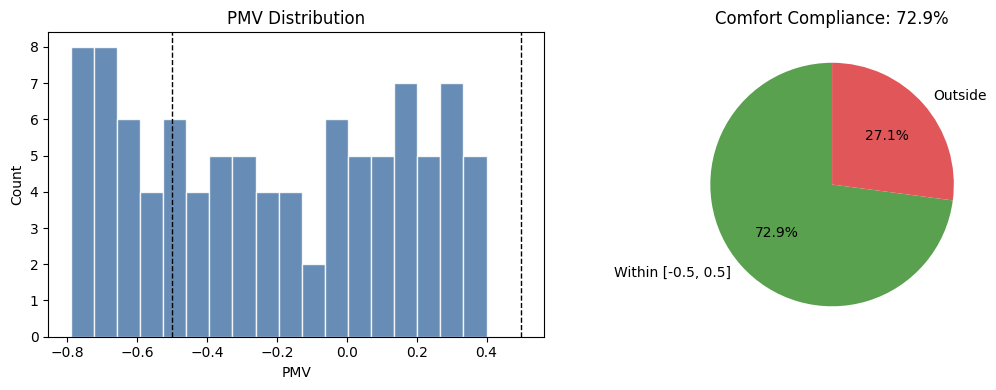

In [3]:
comfortable = df["pmv"].between(-0.5, 0.5)
compliance = comfortable.mean() * 100

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))

ax0.hist(df["pmv"], bins=18, color="#4c78a8", alpha=0.85, edgecolor="white")
ax0.axvline(-0.5, color="black", ls="--", lw=1)
ax0.axvline(0.5, color="black", ls="--", lw=1)
ax0.set_title("PMV Distribution")
ax0.set_xlabel("PMV")
ax0.set_ylabel("Count")

sizes = [comfortable.sum(), (~comfortable).sum()]
labels = ["Within [-0.5, 0.5]", "Outside"]
colors = ["#59a14f", "#e15759"]
ax1.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
ax1.set_title(f"Comfort Compliance: {compliance:.1f}%")

plt.tight_layout()

## 3) Threshold Region Plot + Measured Overlay

Combines model-based PMV regions with measured points to compare expected and observed conditions.


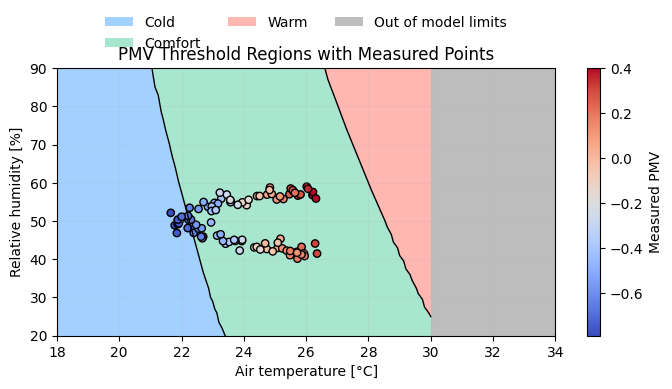

In [4]:
threshold = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 90.0, resolution=0.5)
    .set_params(tr=24.0, vr=0.1, met=1.2, clo=0.5, wme=0.0)
    .set_regions(
        output="pmv", thresholds=[-0.5, 0.5], labels=["Cold", "Comfort", "Warm"]
    )
    .plot(title="PMV Threshold Regions with Measured Points", legend_kws={"ncol": 3})
)

sc = threshold.ax.scatter(
    df["tdb"], df["rh"], c=df["pmv"], cmap="coolwarm", edgecolor="black", s=28
)
plt.colorbar(sc, ax=threshold.ax, label="Measured PMV")
threshold.ax.set_xlabel("Air temperature [°C]")
threshold.ax.set_ylabel("Relative humidity [%]")
threshold.ax.grid(alpha=0.15)
plt.tight_layout()

## 4) UTCI Category Counts (Outdoor Example)

Classifies UTCI results into thermal-stress categories and visualizes frequency by category.


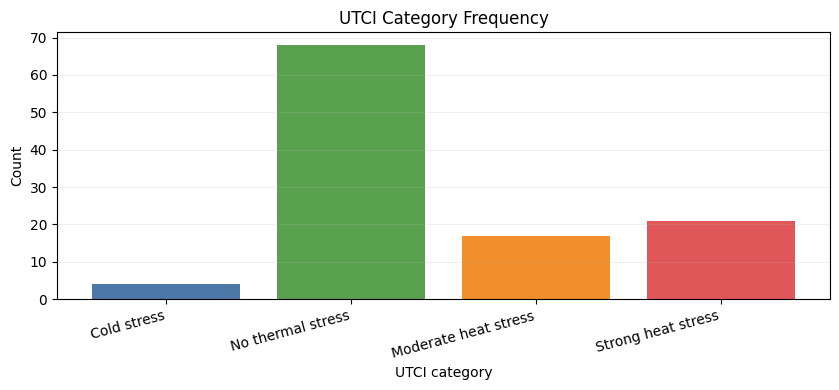

In [5]:
# Synthetic outdoor conditions
m = 120
tout = pd.DataFrame(
    {
        "tdb": rng.uniform(8, 38, m),
        "tr": rng.uniform(8, 40, m),
        "v": rng.uniform(0.2, 3.0, m),
        "rh": rng.uniform(20, 90, m),
    }
)

tout["utci"] = [
    utci(tdb=row.tdb, tr=row.tr, v=row.v, rh=row.rh).utci
    for row in tout.itertuples(index=False)
]

bins = [-np.inf, 9, 26, 32, np.inf]
labels = [
    "Cold stress",
    "No thermal stress",
    "Moderate heat stress",
    "Strong heat stress",
]
tout["utci_cat"] = pd.cut(tout["utci"], bins=bins, labels=labels, right=False)
counts = tout["utci_cat"].value_counts().reindex(labels, fill_value=0)

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(counts.index, counts.values, color=["#4c78a8", "#59a14f", "#f28e2b", "#e15759"])
ax.set_title("UTCI Category Frequency")
ax.set_ylabel("Count")
ax.set_xlabel("UTCI category")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()